## Real Time Censorship, model evaluation

In [106]:
import os
import csv
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

import sys
sys.path.insert(0, os.path.abspath(".."))

from app import config
from app.detector import NsfwDetector
from app.device import pick_device, onnx_providers

ROOT = os.path.abspath("dataset")
DATA_ROOT = os.path.join(ROOT, "nsfw-detector")
NSFW_CLASSES = set(config.NSFW_CLASSES)
DEFAULT_THRESHOLD = config.SCORE_THRESHOLD
RAW_THRESHOLD = 0.02
IOU_MATCH = 0.5

def box_iou(a, b):
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    ix1, iy1 = max(ax, bx), max(ay, by)
    ix2, iy2 = min(ax + aw, bx + bw), min(ay + ah, by + bh)
    iw, ih = max(0.0, ix2 - ix1), max(0.0, iy2 - iy1)
    inter = iw * ih
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0

print("explicit classes:", sorted(NSFW_CLASSES))
print("service threshold:", DEFAULT_THRESHOLD)
print("iou match:", IOU_MATCH)

explicit classes: ['ANUS_EXPOSED', 'BUTTOCKS_EXPOSED', 'FEMALE_BREAST_EXPOSED', 'FEMALE_GENITALIA_EXPOSED', 'MALE_GENITALIA_EXPOSED']
service threshold: 0.25
iou match: 0.5


## Ground truth (nsfw-detector, held out 20 percent)

In [118]:
ground_truth = {}
with open(os.path.join(DATA_ROOT, "annotations.csv")) as handle:
    for row in csv.DictReader(handle):
        if row["label"] not in NSFW_CLASSES:
            continue
        path = os.path.join(DATA_ROOT, "images", row["image"])
        box = [float(row["x"]), float(row["y"]), float(row["w"]), float(row["h"])]
        ground_truth.setdefault(path, []).append({"label": row["label"], "box": box})

ground_truth = {path: objects for path, objects in ground_truth.items() if os.path.exists(path)}
DATASET_LABELS = {obj["label"] for objects in ground_truth.values() for obj in objects}

counts = {}
for objects in ground_truth.values():
    for obj in objects:
        counts[obj["label"]] = counts.get(obj["label"], 0) + 1

print("held out test images", len(ground_truth))
print("ground truth boxes", sum(len(o) for o in ground_truth.values()))
print("per class", sorted(counts.items(), key=lambda item: -item[1]))
print("model classes not annotated here, excluded from scoring:", sorted(NSFW_CLASSES - DATASET_LABELS))

held out test images 2881
ground truth boxes 5711
per class [('FEMALE_BREAST_EXPOSED', 2703), ('BUTTOCKS_EXPOSED', 1075), ('MALE_GENITALIA_EXPOSED', 981), ('FEMALE_GENITALIA_EXPOSED', 952)]
model classes not annotated here, excluded from scoring: ['ANUS_EXPOSED']


## Detection

In [119]:
device = pick_device()
providers = onnx_providers(device)
detector = NsfwDetector(providers)
print("device", device, "providers", providers)

def score_image(path):
    import cv2
    image = cv2.imread(path)
    if image is None:
        return None
    started = time.perf_counter()
    found = detector.detect(image, score_threshold=RAW_THRESHOLD)
    elapsed = (time.perf_counter() - started) * 1000.0
    # only score classes this dataset annotates, a detection of a class it
    # never labels is not a false positive, it is simply unlabeled here
    dets = [d for d in found if d["label"] in DATASET_LABELS]
    return {
        "path": path,
        "dets": dets,
        "gt": ground_truth[path],
        "labels": ",".join(sorted({d["label"] for d in dets})),
        "ms": elapsed,
        "width": image.shape[1],
        "height": image.shape[0],
    }

rows = [score_image(path) for path in sorted(ground_truth)]
rows = [row for row in rows if row is not None]
frame = pd.DataFrame(rows)
print("scored", len(frame), "images")
print("detections", sum(len(d) for d in frame["dets"]), "ground truth boxes", sum(len(g) for g in frame["gt"]))

2026-08-13 18:48:13 model loaded from 320n.onnx active providers CoreMLExecutionProvider,CPUExecutionProvider
device mps providers ['CoreMLExecutionProvider', 'CPUExecutionProvider']


libpng warning: iCCP: extra compressed data


scored 2881 images
detections 9762 ground truth boxes 5711


## Detection metrics: mIoU, mAP50, mAP50-95, error rate

In [122]:
def greedy_match(rows, iou_threshold, score_threshold=0.0):
    preds = []
    for row in rows.itertuples():
        for det in row.dets:
            if det["score"] >= score_threshold:
                preds.append((row.path, det["label"], det["score"], det["box"]))
    preds.sort(key=lambda item: -item[2])
    objects = {row.path: row.gt for row in rows.itertuples()}
    used = {path: [False] * len(objs) for path, objs in objects.items()}
    hits = np.zeros(len(preds), dtype=int)
    matched_ious = []
    for i, (path, label, score, box) in enumerate(preds):
        take_iou, take_j = 0.0, -1
        for j, obj in enumerate(objects[path]):
            if used[path][j] or obj["label"] != label:
                continue
            value = box_iou(box, obj["box"])
            if value > take_iou:
                take_iou, take_j = value, j
        if take_j >= 0 and take_iou >= iou_threshold:
            hits[i] = 1
            used[path][take_j] = True
            matched_ious.append(take_iou)
    scores = np.array([p[2] for p in preds])
    return scores, hits, matched_ious

def average_precision_at(rows, iou_threshold):
    scores, hits, matched_ious = greedy_match(rows, iou_threshold)
    total_gt = sum(len(row.gt) for row in rows.itertuples())
    tp_cum = np.cumsum(hits)
    fp_cum = np.cumsum(1 - hits)
    recall = tp_cum / total_gt if total_gt else np.zeros(len(hits))
    precision = tp_cum / np.maximum(tp_cum + fp_cum, 1)
    ap = 0.0
    for t in np.linspace(0, 1, 101):
        above = precision[recall >= t]
        ap += above.max() if above.size else 0.0
    return ap / 101.0, (float(np.mean(matched_ious)) if matched_ious else 0.0)

def per_class_report(rows, iou_threshold, score_threshold):
    """every ground truth box is matched, box off, or never fired"""
    stats = {}
    for row in rows.itertuples():
        fired = {}
        for det in row.dets:
            if det["score"] >= score_threshold:
                fired.setdefault(det["label"], []).append(det)
        taken = {label: [False] * len(items) for label, items in fired.items()}
        for obj in row.gt:
            entry = stats.setdefault(obj["label"], {"matched": 0, "box_off": 0, "no_fire": 0, "ious": []})
            candidates = fired.get(obj["label"], [])
            take_iou, take_j = 0.0, -1
            for j, det in enumerate(candidates):
                if taken[obj["label"]][j]:
                    continue
                value = box_iou(det["box"], obj["box"])
                if value > take_iou:
                    take_iou, take_j = value, j
            if not candidates:
                entry["no_fire"] += 1
                continue
            if take_j >= 0:
                taken[obj["label"]][take_j] = True
            entry["ious"].append(take_iou)
            if take_iou >= iou_threshold:
                entry["matched"] += 1
            else:
                entry["box_off"] += 1
    table = []
    for label in sorted(stats):
        entry = stats[label]
        total = entry["matched"] + entry["box_off"] + entry["no_fire"]
        table.append({
            "class": label,
            "objects": total,
            "matched": entry["matched"],
            "box off": entry["box_off"],
            "never fired": entry["no_fire"],
            "found %": round(100.0 * (total - entry["no_fire"]) / total, 1),
            "matched %": round(100.0 * entry["matched"] / total, 1),
            "median iou": round(float(np.median(entry["ious"])), 3) if entry["ious"] else float("nan"),
        })
    return pd.DataFrame(table)

map50, miou50 = average_precision_at(frame, IOU_MATCH)
iou_levels = np.round(np.arange(0.5, 1.0, 0.05), 2)
map5095 = float(np.mean([average_precision_at(frame, level)[0] for level in iou_levels]))

report = per_class_report(frame, IOU_MATCH, DEFAULT_THRESHOLD)
total_objects = int(report["objects"].sum())
matched_objects = int(report["matched"].sum())
box_off_objects = int(report["box off"].sum())
never_fired = int(report["never fired"].sum())
found_objects = total_objects - never_fired

print("ground truth boxes", total_objects)
print("mAP50", round(map50, 4))
print("mAP50-95", round(map5095, 4))
print("mIoU of matched boxes", round(miou50, 4))
print("at service threshold", DEFAULT_THRESHOLD, "iou", IOU_MATCH)
print("found:", found_objects, "of", total_objects, "(%.1f percent)" % (100.0 * found_objects / total_objects))
print("matched:", matched_objects, "(%.1f percent)" % (100.0 * matched_objects / total_objects))
print("box off:", box_off_objects)
print("never fired:", never_fired)
report

ground truth boxes 5711
mAP50 0.8341
mAP50-95 0.4591
mIoU of matched boxes 0.7757
at service threshold 0.25 iou 0.5
found: 4903 of 5711 (85.9 percent)
matched: 4525 (79.2 percent)
box off: 378
never fired: 808


,class,objects,matched,box off,never fired,found %,matched %,median iou
0,BUTTOCKS_EXPOSED,1075,824,56,195,81.9,76.7,0.774
1,FEMALE_BREAST_EXPOSED,2703,2275,187,241,91.1,84.2,0.817
2,FEMALE_GENITALIA_EXPOSED,952,698,59,195,79.5,73.3,0.737
3,MALE_GENITALIA_EXPOSED,981,728,76,177,82.0,74.2,0.755


## ROC and PRC

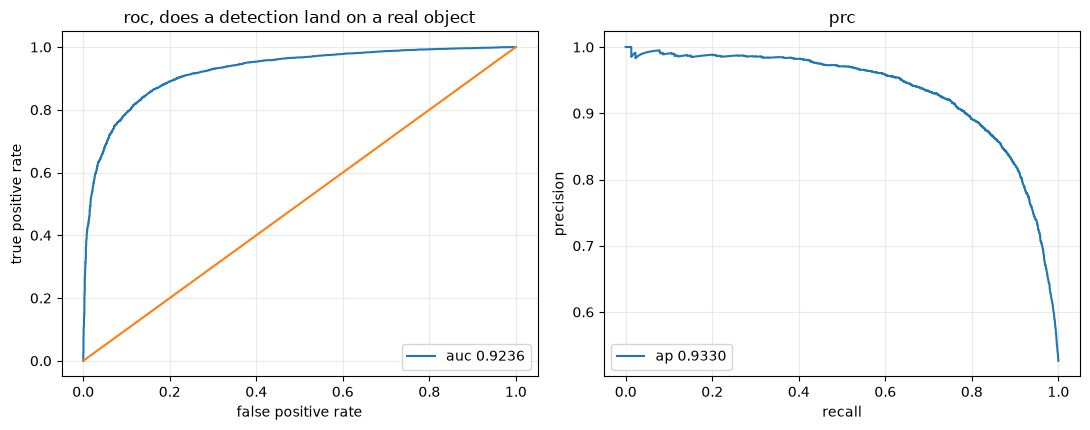

detections 9762 landed on a real object 5138 did not 4624
roc auc 0.9236
average precision (prc auc) 0.933


In [129]:
det_scores, det_hits, _ = greedy_match(frame, IOU_MATCH)

fpr, tpr, _ = roc_curve(det_hits, det_scores)
roc_auc = auc(fpr, tpr)
prec_curve, rec_curve, _ = precision_recall_curve(det_hits, det_scores)
average_precision = average_precision_score(det_hits, det_scores)

figure, axes = plt.subplots(1, 2, figsize=(11, 4.4))
axes[0].plot(fpr, tpr, label="auc %.4f" % roc_auc)
axes[0].plot([0, 1], [0, 1])
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].set_title("roc, does a detection land on a real object")
axes[0].legend(loc="lower right")
axes[0].grid(alpha=0.25)

axes[1].plot(rec_curve, prec_curve, label="ap %.4f" % average_precision)
axes[1].set_xlabel("recall")
axes[1].set_ylabel("precision")
axes[1].set_title("prc")
axes[1].legend(loc="lower left")
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("detections", len(det_scores), "landed on a real object", int(det_hits.sum()),
      "did not", int((1 - det_hits).sum()))
print("roc auc", round(roc_auc, 4))
print("average precision (prc auc)", round(average_precision, 4))

## Threshold sweep

In [124]:
sweep = []
for value in np.round(np.arange(0.05, 0.96, 0.05), 2):
    table = per_class_report(frame, IOU_MATCH, value)
    objects = int(table["objects"].sum())
    matched = int(table["matched"].sum())
    fired = objects - int(table["never fired"].sum())
    sweep.append({"threshold": value,
                  "found rate": round(fired / objects, 4),
                  "matched rate": round(matched / objects, 4),
                  "never fired": objects - fired})

sweep_frame = pd.DataFrame(sweep)
best = sweep_frame.loc[sweep_frame["matched rate"].idxmax()]
print("best matched rate", best["matched rate"], "at threshold", best["threshold"])
sweep_frame

best matched rate 0.8781 at threshold 0.05


,threshold,found rate,matched rate,never fired
0,0.05,0.9436,0.8781,322
1,0.10,0.9193,0.8543,461
2,0.15,0.8970,0.8326,588
3,0.20,0.8766,0.8126,705
4,0.25,0.8585,0.7923,808
5,0.30,0.8337,0.7666,950
6,0.35,0.8048,0.7377,1115
7,0.40,0.7736,0.7048,1293
8,0.45,0.7375,0.6703,1499
9,0.50,0.6948,0.6263,1743


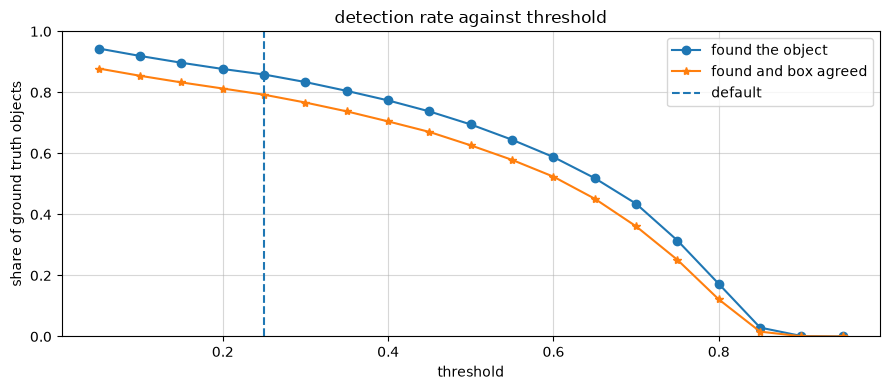

In [125]:
figure, axis = plt.subplots(figsize=(9, 4))
axis.plot(sweep_frame["threshold"], sweep_frame["found rate"], marker="o", label="found the object")
axis.plot(sweep_frame["threshold"], sweep_frame["matched rate"], marker="*", label="found and box agreed")
axis.axvline(DEFAULT_THRESHOLD, linestyle="--", label="default")
axis.set_xlabel("threshold")
axis.set_ylabel("share of ground truth objects")
axis.set_title("detection rate against threshold")
axis.set_ylim(0, 1)
axis.legend()
axis.grid(alpha=0.5)
plt.tight_layout()
plt.show()

## What fires, and how fast

In [126]:
hits = frame[frame["labels"] != ""]
counter = {}
for row in hits["labels"]:
    for name in row.split(","):
        counter[name] = counter.get(name, 0) + 1
class_frame = pd.DataFrame(sorted(counter.items(), key=lambda item: -item[1]), columns=["class", "images"])
print("latency mean %.1f ms, median %.1f ms, p95 %.1f ms" % (
    frame["ms"].mean(), frame["ms"].median(), frame["ms"].quantile(0.95)))
print("median image size %d x %d" % (frame["width"].median(), frame["height"].median()))
class_frame

latency mean 10.7 ms, median 10.4 ms, p95 12.4 ms
median image size 470 x 320


,class,images
0,FEMALE_BREAST_EXPOSED,1923
1,BUTTOCKS_EXPOSED,1593
2,FEMALE_GENITALIA_EXPOSED,1327
3,MALE_GENITALIA_EXPOSED,1233


## Random sample with detections

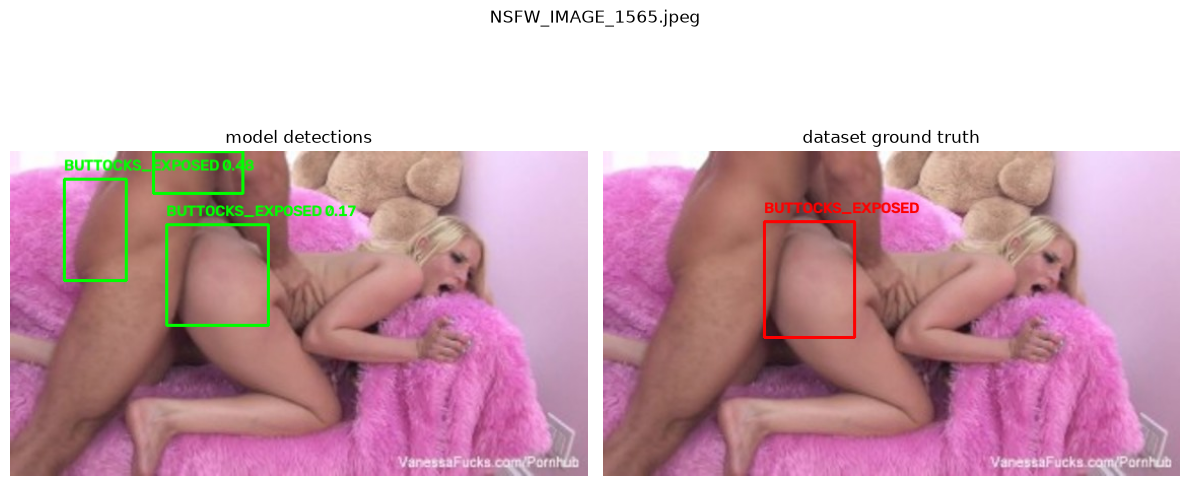

NSFW_IMAGE_1565.jpeg detections: 3 ground truth boxes: 1


In [127]:
import random
import cv2

sample_path = random.choice(list(frame["path"]))

det_image = cv2.imread(sample_path)
found = [d for d in detector.detect(det_image, score_threshold=RAW_THRESHOLD) if d["label"] in NSFW_CLASSES]
for det in found:
    x, y, w, h = [int(v) for v in det["box"]]
    cv2.rectangle(det_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    text = "%s %.2f" % (det["label"], det["score"])
    cv2.putText(det_image, text, (x, max(0, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

gt_image = cv2.imread(sample_path)
for obj in ground_truth[sample_path]:
    x, y, w, h = [int(v) for v in obj["box"]]
    cv2.rectangle(gt_image, (x, y), (x + w, y + h), (0, 0, 255), 2)
    cv2.putText(gt_image, obj["label"], (x, max(0, y - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)

figure, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(cv2.cvtColor(det_image, cv2.COLOR_BGR2RGB))
axes[0].set_title("model detections")
axes[0].axis("off")
axes[1].imshow(cv2.cvtColor(gt_image, cv2.COLOR_BGR2RGB))
axes[1].set_title("dataset ground truth")
axes[1].axis("off")
figure.suptitle(os.path.basename(sample_path))
plt.tight_layout()
plt.show()

print(os.path.basename(sample_path), "detections:", len(found),
      "ground truth boxes:", len(ground_truth[sample_path]))

## Result

In [128]:
print("mAP50:", round(map50, 4))
print("mAP50-95:", round(map5095, 4))
print("mIoU:", round(miou50, 4))
print("ROC AUC:", round(roc_auc, 4))
print("PRC average precision:", round(average_precision, 4))
print("At service threshold", DEFAULT_THRESHOLD, "iou", IOU_MATCH)
print("Found:", round(100.0 * found_objects / total_objects, 1), "%")
print("Matched:", round(100.0 * matched_objects / total_objects, 1), "%")
print("Best matched rate:", best["matched rate"], "at threshold", best["threshold"])
print("Device:", device)
print("Mean latency:", round(frame["ms"].mean(), 1), "ms")
print("Median latency:", round(frame["ms"].median(), 1), "ms")
print("P95 latency:", round(frame["ms"].quantile(0.95), 1), "ms")

mAP50: 0.8341
mAP50-95: 0.4591
mIoU: 0.7757
ROC AUC: 0.9236
PRC average precision: 0.933
At service threshold 0.25 iou 0.5
Found: 85.9 %
Matched: 79.2 %
Best matched rate: 0.8781 at threshold 0.05
Device: mps
Mean latency: 10.7 ms
Median latency: 10.4 ms
P95 latency: 12.4 ms
